<a href="https://colab.research.google.com/github/alminha021/DS-rcf/blob/main/Int_Ciencias_de_Dados_NBA_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Equipe:**

Runaldo Lopes de Souza

Raul Costa Feitosa

#**Analise Exploratória dos Dataset - NBA**

## 1. **Introdução**

A altura influencia no desempenho dos jogadores da NBA? Essa pergunta deve ser respondida ou não com base na exploração do Dataset. Quais metricas podem apontam em direção a resposta desse pergunta.

## 2. **Importação de Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import gdown as gd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib as mpl


##3. **Carregamento e Exploração Inicial dos Dados**

3.1   ***Carregar o dataset.***

In [2]:
# URL direta do ficheiro no Google Drive
url = "https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK"


# Nome do ficheiro local
output = "nba_stats.csv"

# Fazer download do CSV
gd.download(url, output, quiet=False)

# Ler o CSV com pandas
df = pd.read_csv(output)

# Mostrar as primeiras linhas
#print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK
To: /content/nba_stats.csv
100%|██████████| 3.50M/3.50M [00:00<00:00, 77.3MB/s]


3.2   ***Ver o número de linhas e Colunas***

In [3]:
# Número de linhas e colunas
linhas, colunas = df.shape
print(f"O dataset tem {linhas} linhas e {colunas} colunas.")

O dataset tem 8162 linhas e 54 colunas.


3.3   ***Exibir algumas amostras (head()).***

In [4]:
df.head(2)

,year,name,playerId,playerSlug,positionId,teamId,status,gamesPlayed,avgMinutes,avgFouls,...,position,birthdate,college,draftinfo,birthplace,team,htwt,experience,rankingSalary,salary
0,1999,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,41.458332,2.041667,...,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,15,"$9,000,000"
1,2000,Allen Iverson,366,allen-iverson,SG,PHI,inactive,70.0,40.757140,2.314286,...,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,27,"$10,125,000"


3.2 **Ver o número de linhas e Colunas**

In [5]:
# Número de linhas e colunas
linhas, colunas = df.shape
print(f"O dataset tem {linhas} linhas e {colunas} colunas.")

O dataset tem 8162 linhas e 54 colunas.


3.3 **Exibir algumas amostras (head()).**

In [6]:
df.head(2)

,year,name,playerId,playerSlug,positionId,teamId,status,gamesPlayed,avgMinutes,avgFouls,...,position,birthdate,college,draftinfo,birthplace,team,htwt,experience,rankingSalary,salary
0,1999,Allen Iverson,366,allen-iverson,SG,PHI,inactive,48.0,41.458332,2.041667,...,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,15,"$9,000,000"
1,2000,Allen Iverson,366,allen-iverson,SG,PHI,inactive,70.0,40.757140,2.314286,...,Shooting Guard,6/7/1975,Georgetown,"1996: Rd 1, Pk 1 (PHI)","Hampton, VA",NaN,NaN,NaN,27,"$10,125,000"


3.4 **Ver tipos de dados (df.info()).**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8162 entries, 0 to 8161
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              8162 non-null   int64  
 1   name                              8162 non-null   object 
 2   playerId                          8162 non-null   int64  
 3   playerSlug                        8162 non-null   object 
 4   positionId                        8156 non-null   object 
 5   teamId                            8162 non-null   object 
 6   status                            8162 non-null   object 
 7   gamesPlayed                       8162 non-null   float64
 8   avgMinutes                        8162 non-null   float64
 9   avgFouls                          8162 non-null   float64
 10  flagrantFouls                     8162 non-null   float64
 11  technicalFouls                    8162 non-null   float64
 12  ejecti

3.5   ***Checar apenas valores ausentes (df.isna().sum()).***

In [8]:
# Mostrar apenas colunas com valores ausentes
missing = df.isnull().sum()
missing[missing > 0]

,0
positionId,6
college,1412
draftinfo,1185
birthplace,215
team,5858
htwt,5858
experience,5858


##4. **Pré-processamento**

4.1 **Transforma a coluna "htwt" em duas: altura e peso, em valores de altura(cm) e peso(kg), em seguida excluo ela.**

In [9]:
def converter_altura_peso(valor):
    # Separar altura e peso
    try:
        altura_str, peso_str = valor.split(", ")

        # Converter altura (ex: "6' 8"")
        pés, polegadas = altura_str.split("' ")
        pés = int(pés.strip())
        polegadas = int(polegadas.replace('"', '').strip())
        altura_cm = round((pés * 12 + polegadas) * 2.54, 1)  # 1 polegada = 2.54 cm

        # Converter peso (ex: "218 lbs")
        peso_lbs = int(peso_str.replace("lbs", "").strip())
        peso_kg = round(peso_lbs * 0.453592, 1)  # 1 libra = 0.453592 kg

        return pd.Series([altura_cm, peso_kg])
    except:
        return pd.Series([None, None])


In [10]:
#Cria as colunas "altura_cm" e "peso_kg" e transforma os valores em  altura em (cm) e peso em (kg)
df[['altura_cm', 'peso_kg']] = df['htwt'].apply(converter_altura_peso)

In [11]:
# Remove a coluna original
df = df.drop(columns=['htwt'])

4.2 Quando aplicado o tratamento de remoção de valores nulos sobre a coluna "altura_cm". As colunas: **positionId, team,experience, peso_kg**, tiveram seus valores nulos eliminados junto, restando apenas tratar as colunas: college, draftinfo, birthplace. Seguida aplico a remoção das três colunas por não aparesentar uma relação significativa com a altura dos jogadores.Considerando que a questão central desta pesquisa é avaliar se a altura influencia positivamente o desempenho dos jogadores da NBA.

In [12]:
# Remove linhas onde 'altura_cm' é NaN
df = df.dropna(subset=['altura_cm'])
df_sb = df.copy() #utilizado em outas analises mais adiante

In [13]:
# Remover colunas desnecessárias
df = df.drop(columns=["college", "draftinfo", "birthplace"])

##5. **Análise Exploratória de Dados (EDA)**

5.1 **Estatistica descritiva df.describe().**

In [14]:
df.describe()

,year,playerId,gamesPlayed,avgMinutes,avgFouls,flagrantFouls,technicalFouls,ejections,doubleDouble,tripleDouble,...,freeThrowsAttempted,assists,turnovers,avgSteals,avgBlocks,steals,blocks,rankingSalary,altura_cm,peso_kg
count,2304.000000,2.304000e+03,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,...,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000
mean,2018.628038,2.138984e+06,59.563802,24.423871,1.994698,0.328993,2.248264,0.151910,7.034722,0.413628,...,164.375000,161.566840,91.346788,0.793661,0.517900,50.150608,32.549479,194.259549,200.175260,100.192752
std,3.887823,1.795100e+06,19.165556,8.709524,0.689514,0.667014,3.127067,0.452153,11.788983,2.222415,...,147.578759,149.256376,66.231741,0.443350,0.471503,34.077411,33.106732,134.997500,8.461176,11.699369
min,2001.000000,5.580000e+02,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,177.800000,74.400000
25%,2016.000000,4.249000e+03,50.000000,17.936302,1.553337,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.750000,55.750000,42.000000,0.475560,0.203390,25.000000,11.000000,75.000000,193.000000,90.700000
50%,2020.000000,2.595812e+06,64.000000,25.592257,2.013514,0.000000,1.000000,0.000000,2.000000,0.000000,...,124.000000,114.000000,77.000000,0.727834,0.373134,45.000000,22.000000,180.000000,200.700000,99.800000
75%,2022.000000,3.914044e+06,75.000000,31.915623,2.473190,0.000000,3.000000,0.000000,8.000000,0.000000,...,225.000000,223.250000,126.000000,1.024199,0.676757,69.000000,42.000000,291.000000,205.700000,108.900000
max,2023.000000,4.997528e+06,83.000000,42.544304,4.875000,5.000000,17.000000,5.000000,69.000000,42.000000,...,881.000000,925.000000,464.000000,2.769231,3.651515,217.000000,242.000000,599.000000,223.500000,131.500000


5.2 **Mostra a distribuição de altura dos jogadores atraves do histograma.**

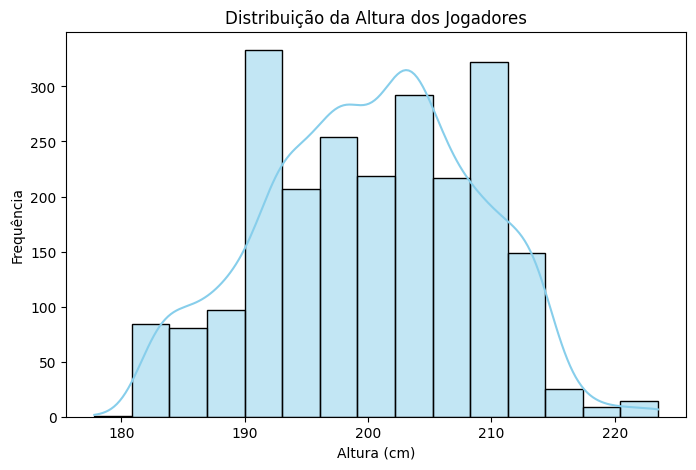

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["altura_cm"], bins=15, kde=True, color="skyblue")
plt.title("Distribuição da Altura dos Jogadores")
plt.xlabel("Altura (cm)")
plt.ylabel("Frequência")
plt.show()

5.3 **Quartis (Boxplot) → Mostra a altura dos jogadores em quartis.**

Quartis da altura (cm):
Q1 (25%): 193.00 → 25% dos jogadores têm altura menor que isso.
Q2 (Mediana): 200.70 → 50% dos jogadores estão abaixo/50% acima.
Q3 (75%): 205.70 → 75% dos jogadores têm altura menor que isso.
IQR (Q3-Q1): 12.70 → Faixa onde está a metade central dos dados.


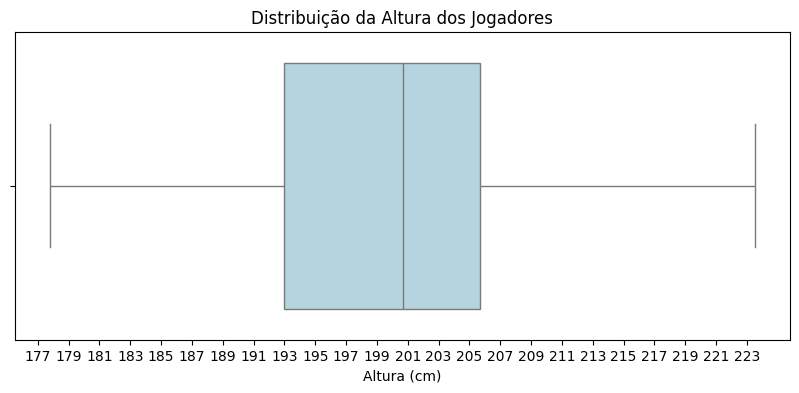

In [16]:
# Quartis da altura
Q1 = df["altura_cm"].quantile(0.25)
Q2 = df["altura_cm"].quantile(0.50)  # Mediana
Q3 = df["altura_cm"].quantile(0.75)
IQR = Q3 - Q1

print("Quartis da altura (cm):")
print(f"Q1 (25%): {Q1:.2f} → 25% dos jogadores têm altura menor que isso.")
print(f"Q2 (Mediana): {Q2:.2f} → 50% dos jogadores estão abaixo/50% acima.")
print(f"Q3 (75%): {Q3:.2f} → 75% dos jogadores têm altura menor que isso.")
print(f"IQR (Q3-Q1): {IQR:.2f} → Faixa onde está a metade central dos dados.")

plt.figure(figsize=(10,4))
sns.boxplot(x=df["altura_cm"], color="lightblue", fliersize=5)
plt.title("Distribuição da Altura dos Jogadores")
plt.xlabel("Altura (cm)")

# Definindo ticks de 2 em 2 cm
plt.xticks(np.arange(int(df["altura_cm"].min()), int(df["altura_cm"].max())+1, 2))

plt.show()



In [17]:
# Alterar altura do jogador para xxx cm (outlier) Valor Original =203.2
df.loc[df["playerId"] == 558, "altura_cm"] = 203.2

Quartis da altura (cm):
Q1 (25%): 193.00 → 25% dos jogadores têm altura menor que isso.
Q2 (Mediana): 200.70 → 50% dos jogadores estão abaixo/50% acima.
Q3 (75%): 205.70 → 75% dos jogadores têm altura menor que isso.
IQR (Q3-Q1): 12.70 → Faixa onde está a metade central dos dados.


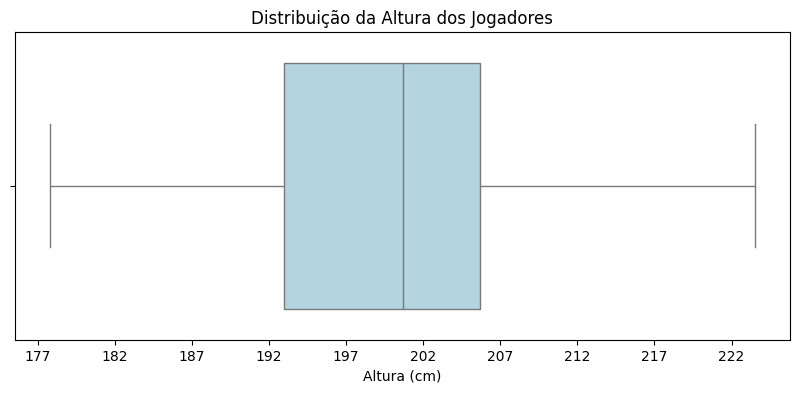

In [18]:
# Quartis da altura
Q1 = df["altura_cm"].quantile(0.25)
Q2 = df["altura_cm"].quantile(0.50)  # Mediana
Q3 = df["altura_cm"].quantile(0.75)
IQR = Q3 - Q1

print("Quartis da altura (cm):")
print(f"Q1 (25%): {Q1:.2f} → 25% dos jogadores têm altura menor que isso.")
print(f"Q2 (Mediana): {Q2:.2f} → 50% dos jogadores estão abaixo/50% acima.")
print(f"Q3 (75%): {Q3:.2f} → 75% dos jogadores têm altura menor que isso.")
print(f"IQR (Q3-Q1): {IQR:.2f} → Faixa onde está a metade central dos dados.")

plt.figure(figsize=(10,4))
sns.boxplot(x=df["altura_cm"], color="lightblue", fliersize=5)
plt.title("Distribuição da Altura dos Jogadores")
plt.xlabel("Altura (cm)")

# Definindo ticks de 2 em 2 cm
plt.xticks(np.arange(int(df["altura_cm"].min()), int(df["altura_cm"].max())+1, 5))

plt.show()



5.4 **Correlação de Pearson da Altura com Outras Variáveis**

In [19]:
df['salary_numeric'] = df['salary'].replace(r'[\$,]', '', regex=True).astype(float)

/tmp/ipython-input-644232160.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


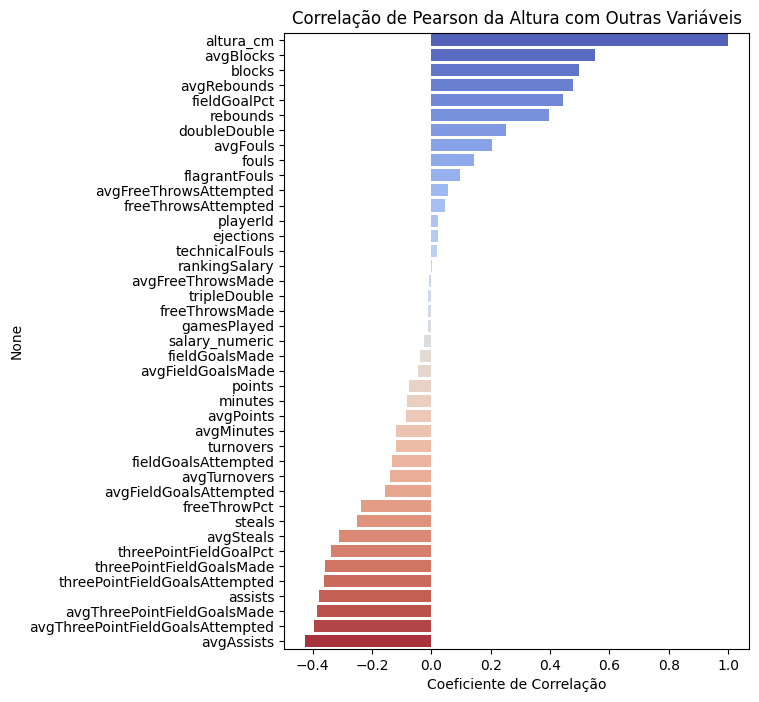

In [20]:
colunas_numericas = [
    'playerId', 'gamesPlayed', 'avgMinutes', 'avgFouls', 'flagrantFouls',
    'technicalFouls', 'ejections', 'doubleDouble', 'tripleDouble', 'minutes',
    'rebounds', 'fouls', 'avgRebounds', 'avgPoints', 'avgFieldGoalsMade',
    'avgFieldGoalsAttempted', 'fieldGoalPct', 'avgThreePointFieldGoalsMade',
    'avgThreePointFieldGoalsAttempted', 'threePointFieldGoalPct',
    'avgFreeThrowsMade', 'avgFreeThrowsAttempted', 'freeThrowPct',
    'avgAssists', 'avgTurnovers', 'points', 'fieldGoalsMade',
    'fieldGoalsAttempted', 'threePointFieldGoalsMade', 'threePointFieldGoalsAttempted',
    'freeThrowsMade', 'freeThrowsAttempted', 'assists', 'turnovers',
    'avgSteals', 'avgBlocks', 'steals', 'blocks', 'rankingSalary', 'altura_cm','salary_numeric'
]

df_numericas = df[colunas_numericas]

# Correlação de Pearson com altura
correlacao_altura = df_numericas.corr()['altura_cm'].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(
    x=correlacao_altura.values,
    y=correlacao_altura.index,
    palette=sns.color_palette("coolwarm", len(correlacao_altura))  # evita warning
)
plt.title("Correlação de Pearson da Altura com Outras Variáveis")
plt.xlabel("Coeficiente de Correlação")
plt.show()

**Insight do gráfico**

*   **Altura** tem correlação fraca ou **quase nula** com várias métricas ofensivas como **avgPoints(Pontos), avgAssists(Assistencia) e avgSteals(Roubo de Bolas)**
*   **jogadores muito altos** tendem a ter **menos mobilidade** ou menos agilidade, o que pode **reduzir assistências ou roubos de bola**
* **A altura** aparece **correlacionada positivamente** com variáveis relacionadas a defesa e jogo próximo ao garrafão (**rebounds - Rebotes do jogador, blocks - Tocos)**.

5.5 **Filtrar apenas correlações fortes.**

/tmp/ipython-input-1540327636.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


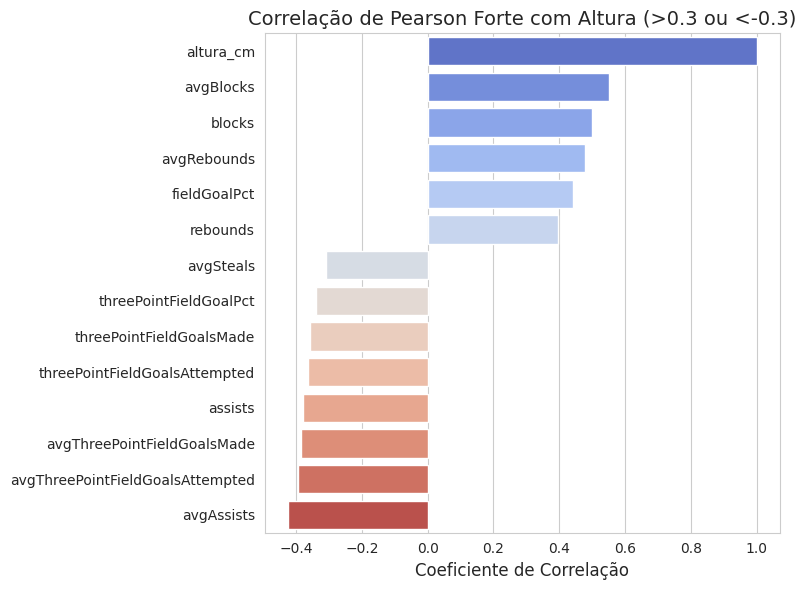

In [21]:
# Vamos filtrar apenas as correlações fortes (absoluta > 0.3) para foco
correlacao_forte = correlacao_altura[correlacao_altura.abs() > 0.3]

# Configurar estilo
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))

# Plot moderno usando barplot sem warnings
sns.barplot(
    x=correlacao_forte.values,
    y=correlacao_forte.index,
    palette=sns.color_palette("coolwarm", len(correlacao_forte))
)

plt.title("Correlação de Pearson Forte com Altura (>0.3 ou <-0.3)", fontsize=14)
plt.xlabel("Coeficiente de Correlação", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()


**Insights do Gráfico Filtrado**

*  Rebotes (avgRebounds) → forte correlação positiva.

Jogadores mais altos têm clara vantagem para pegar rebotes, o que é esperado pelo alcance físico.

Esse é um desempenho diretamente ligado à altura.

---

*  Tocos (avgBlocks) → forte correlação positiva.

Jogadores altos conseguem proteger melhor o aro.

Isso reforça que altura está ligada ao papel defensivo.


**5.6 Grafico de bubbles para visualizar a distribuição geográfica dos jogadores**

Usado o gráfico de bubbles sobre o mapa dos EUA baseado no birthplace dos jogadores para visualizar a distribuição geográfica dos jogadores mais altos.
O tamanho das bolhas representa a altura, permitindo identificar rapidamente regiões que produziram jogadores mais altos.
Esse tipo de gráfico ajuda a verificar tendências espaciais ou padrões regionais sem precisar de muitas tabelas numéricas.

In [22]:
# Dicionário de siglas → nomes de estados
state_names = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming"
}




In [23]:
df_unique = df_sb.drop_duplicates(subset=["playerId"]).copy()
df_unique["state"] = df_unique["birthplace"].str.extract(r",\s*([A-Z]{2})")

# Contagem de jogadores por estado + altura
height_dist = df_unique.groupby(["state", "altura_cm"]).size().reset_index(name="count")
height_dist["state_name"] = height_dist["state"].map(state_names)


# Adicionar coluna de nomes completos
height_dist["state_name"] = height_dist["state"].map(state_names)

fig = px.scatter_geo(
    height_dist,
    locations="state",
    locationmode="USA-states",
    size="count",           # bolha cresce se houver muitos jogadores com essa altura
    color="altura_cm",      # cor representa a altura real
    hover_name="state_name", # nome completo aparece no hover
    hover_data={"state":True, "altura_cm":True, "count":True}, # mostrar também inicial, altura e qtd
    scope="usa",
    title="Distribuição das alturas dos jogadores por estado (únicos)"
)

fig.update_traces(marker=dict(line=dict(width=0), sizemode="area"))
fig.show()


**5.7 Gráficos de barras com erro para comparar métricas por estado**

O gráfico de barras com barras de erro mostra médias de métricas (ex.: salário, pontos, rebotes) por grupo, como estado de nascimento, posição ou faixa de altura, com a variação/erro padrão indicada pelas barras verticais.
Esse gráfico facilita a comparação entre grupos, evidenciando quais estados ou categorias se destacam e quais têm mais variabilidade.

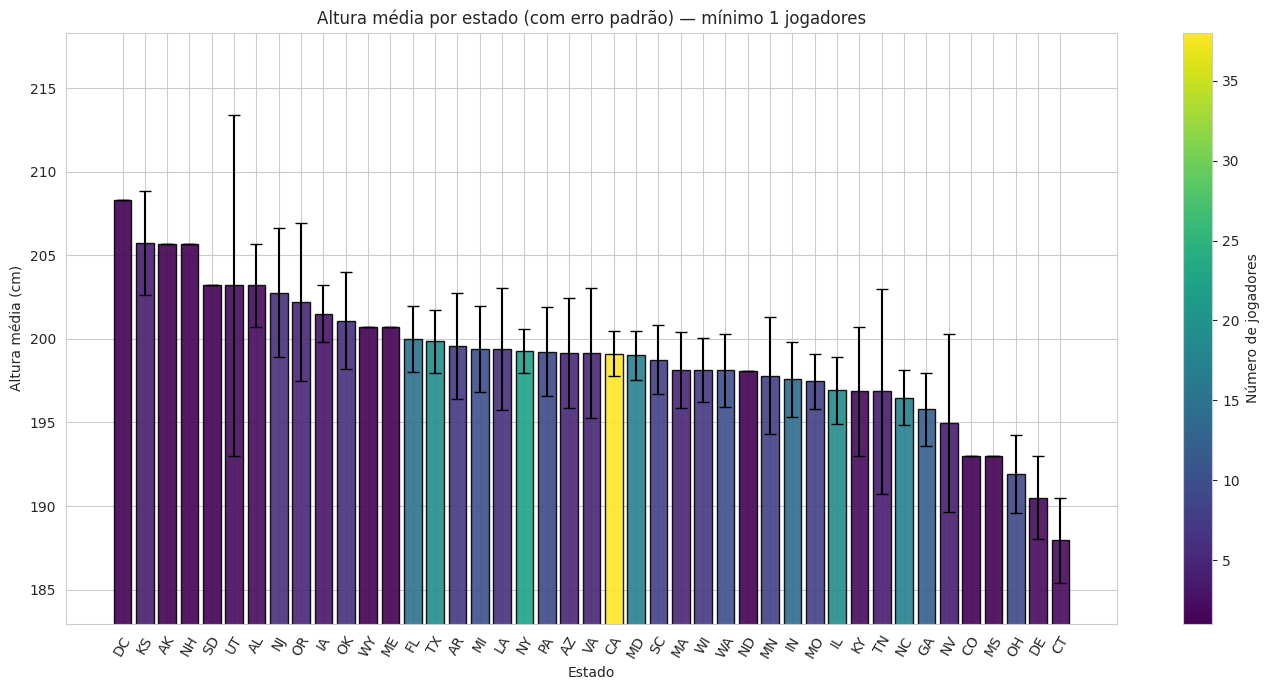

In [24]:
# =========================
# Gráfico: Altura média por estado (com erro padrão e cor por nº de jogadores)
# =========================
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- Configurável: mínimo de jogadores por estado para entrar no gráfico
MIN_COUNT = 1   # mude para 1, 5, etc, se quiser

# 0) Escolher a base: usa df_sb se existir; senão, df
try:
    source_df = df_sb.copy()
except NameError:
    source_df = df.copy()

# 1) Linhas únicas por jogador e tipos corretos
df_unique = source_df.drop_duplicates(subset=["playerId"]).copy()
df_unique["altura_cm"] = pd.to_numeric(df_unique["altura_cm"], errors="coerce")
df_unique["birthplace"] = df_unique["birthplace"].astype(str)

# 2) Extrair sigla do estado (ex.: "City, CA" -> "CA")
df_unique["state"] = df_unique["birthplace"].str.extract(r",\s*([A-Z]{2})")[0]

# (opcional) manter apenas estados/territórios EUA (ajuste se houver outros países)
valid_states = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA","KS","KY","LA","ME",
    "MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ","NM","NY","NC","ND","OH","OK","OR","PA",
    "RI","SC","SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"
}
df_unique = df_unique[df_unique["state"].isin(valid_states)]

# 3) Remover NaN essenciais
df_unique = df_unique.dropna(subset=["state", "altura_cm"])

# 4) Agregar por estado: count, média, std -> SEM (erro padrão)
agg = (
    df_unique.groupby("state")["altura_cm"]
    .agg(["count", "mean", "std"])
    .reset_index()
)
# SEM = std / sqrt(n) (se n < 2, define 0 para evitar NaN)
agg["sem"] = np.where(agg["count"] >= 2, agg["std"] / np.sqrt(agg["count"]), 0.0)

# 5) Renomear e filtrar por mínimo de observações
state_stats = agg.rename(columns={"mean": "avg_height", "sem": "sem_height"}).drop(columns=["std"])
state_stats = state_stats[state_stats["count"] >= MIN_COUNT]

# 6) Ordenar
state_stats_sorted = state_stats.sort_values("avg_height", ascending=False).reset_index(drop=True)

# --- Se não houver dados suficientes, evita quebrar ---
if state_stats_sorted.empty:
    print("Sem dados suficientes para plotar (verifique 'birthplace', 'altura_cm' e MIN_COUNT).")
else:
    # --- GRÁFICO ---
    fig, ax = plt.subplots(figsize=(14, 7))

    # Normalização das cores pelo nº de jogadores
    norm = mpl.colors.Normalize(
        vmin=state_stats_sorted["count"].min(),
        vmax=state_stats_sorted["count"].max()
    )
    cmap = plt.cm.viridis
    colors = cmap(norm(state_stats_sorted["count"]))

    # yerr: substituir NaN por 0 para evitar erro
    yerr_vals = state_stats_sorted["sem_height"].fillna(0.0).values

    bars = ax.bar(
        state_stats_sorted["state"],
        state_stats_sorted["avg_height"],
        yerr=yerr_vals,
        capsize=4,
        alpha=0.9,
        color=colors,
        edgecolor="black"
    )

    # Rótulos do eixo X (categorias)
    ax.set_xticks(range(len(state_stats_sorted)))
    ax.set_xticklabels(state_stats_sorted["state"], rotation=60, ha="center")

    # Ajuste do eixo Y (somente se finito)
    min_height = state_stats_sorted["avg_height"].min()
    max_height = state_stats_sorted["avg_height"].max()
    if np.isfinite(min_height) and np.isfinite(max_height):
        ax.set_ylim(min_height - 5, max_height + 10)

    ax.set_ylabel("Altura média (cm)")
    ax.set_xlabel("Estado")
    ax.set_title(f"Altura média por estado (com erro padrão) — mínimo {MIN_COUNT} jogadores")

    # Barra de cor (nº de jogadores)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Número de jogadores")

    plt.tight_layout()
    plt.show()


**5.8 Gráfico de violino para análise de métricas por faixa de altura**

/tmp/ipython-input-1211764717.py:2: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.



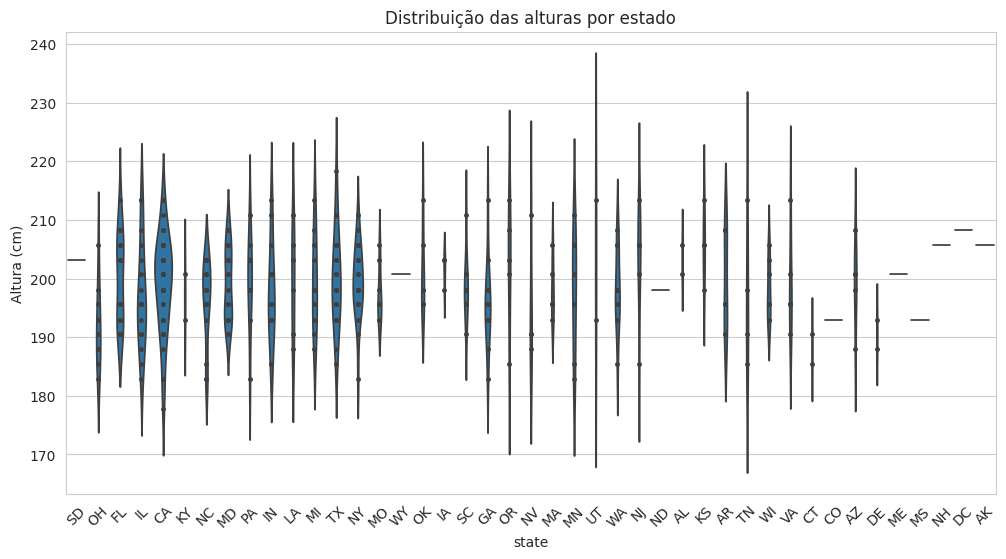

In [25]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df_unique, x="state", y="altura_cm", inner="point", scale="count")
plt.xticks(rotation=45)
plt.ylabel("Altura (cm)")
plt.title("Distribuição das alturas por estado")
plt.show()


O gráfico de violino combina boxplot e kernel density plot para mostrar a distribuição dos dados.
Ele é especialmente útil para comparar a dispersão e densidade de uma métrica entre grupos diferentes (ex.: alturas por posição ou salários por estado).
Permite ver não só a mediana e quartis, mas também a forma da distribuição de cada grupo, incluindo múltiplos picos.

In [26]:
state_counts = df_unique.groupby("state", as_index=False)["playerId"].nunique()
state_counts = state_counts.rename(columns={"playerId": "num_players"})
state_counts = state_counts.sort_values(by="num_players", ascending=False)
print(state_counts[['state', 'num_players']].to_string(index=False))


state  num_players
   CA           38
   NY           22
   IL           19
   TX           19
   MD           17
   NC           17
   FL           15
   IN           14
   GA           12
   WA           10
   MI           10
   OH            9
   PA            9
   SC            8
   MO            8
   MN            8
   WI            7
   AR            7
   OK            6
   NJ            6
   LA            6
   VA            5
   OR            5
   AZ            5
   MA            5
   TN            4
   NV            4
   KS            4
   IA            3
   KY            2
   UT            2
   AL            2
   DE            2
   CT            2
   AK            1
   DC            1
   CO            1
   MS            1
   ME            1
   NH            1
   ND            1
   SD            1
   WY            1


Análise por estado usando gráficos de barras e violino:
Com base nos gráficos de barras e violino, percebe-se que o dataset possui uma concentração maior de jogadores oriundos da Califórnia (CA). Por conta desse maior número de jogadores, podemos ter mais confiança na estimativa da altura média produzida por esse estado.

Para os outros estados, a maioria possui poucos jogadores, às vezes apenas um, o que limita a confiabilidade das médias e distribuições observadas. É importante ter cautela ao tirar conclusões para esses estados, já que o dataset é relativamente pequeno e pode não ser representativo de toda a população de jogadores de basquete.

In [27]:
# Primeiro, convertemos o salário para numérico
df_sb['salary_numeric'] = df_sb['salary'].replace(r'[\$,]', '', regex=True).astype(float)

# Agora pegamos a linha com maior salário para cada playerId
df_unique_salary = df_sb.loc[df_sb.groupby('playerId')['salary_numeric'].idxmax()].copy()

# Conferir
#print(df_unique_salary.head())


**5.9 Comparação de radar por faixas de altura**

/tmp/ipython-input-2471959288.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-2471959288.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



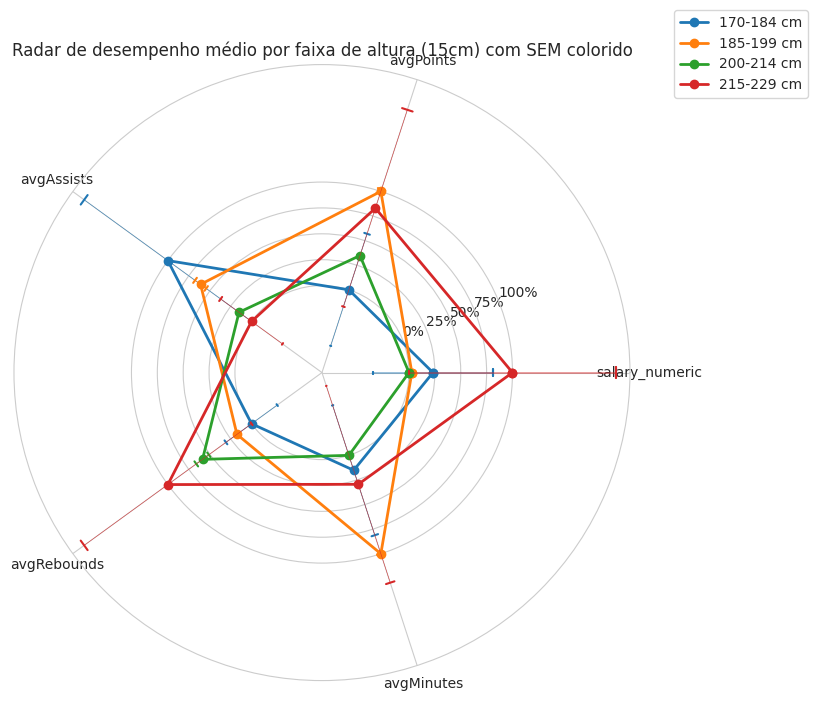

In [28]:
df_unique_salary = df_sb.sort_values("salary_numeric", ascending=False).drop_duplicates(subset=["playerId"]).copy()

#Criar faixas de altura a cada 15 cm
min_height = int(df_unique_salary["altura_cm"].min() // 10 * 10)
max_height = int(df_unique_salary["altura_cm"].max() // 10 * 10 + 15)
bins = list(range(min_height, max_height+1, 15))
labels = [f"{b}-{b+14} cm" for b in bins[:-1]]
df_unique_salary["height_group"] = pd.cut(df_unique_salary["altura_cm"], bins=bins, labels=labels, include_lowest=True)



metrics = ["salary_numeric", "avgPoints", "avgAssists", "avgRebounds", "avgMinutes"]

radar_mean = df_unique_salary.groupby("height_group")[metrics].mean()
radar_sem = df_unique_salary.groupby("height_group")[metrics].sem().fillna(0)

# Normaliza
radar_mean_scaled = radar_mean.copy()
radar_sem_scaled = radar_sem.copy()
for col in metrics:
    scaler = MinMaxScaler()
    radar_mean_scaled[[col]] = scaler.fit_transform(radar_mean[[col]])
    radar_sem_scaled[[col]] = scaler.fit_transform(radar_sem[[col]])


# Plotar radar com "barras de erro" coloridas
def plot_radar_with_colored_errorbars(df_mean, df_sem, metrics):
    categories = metrics
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # fechar círculo

    fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

    for hg in df_mean.index:
        values = df_mean.loc[hg].tolist()
        sem_values = df_sem.loc[hg].tolist()
        values += values[:1]
        sem_values += sem_values[:1]

        # Linha média
        line, = ax.plot(angles, values, label=hg, linewidth=2, marker='o')
        color = line.get_color()  # pega a cor da linha do radar

        # Barras de erro discretas |-| nos vértices com a mesma cor
        for angle, val, sem in zip(angles, values, sem_values):
            ax.plot([angle, angle], [val - sem, val + sem], color=color, linewidth=0.35)  # barra vertical
            ax.plot([angle-0.02, angle+0.02], [val - sem, val - sem], color=color, linewidth=1.5)  # t
            ax.plot([angle-0.02, angle+0.02], [val + sem, val + sem], color=color, linewidth=1.5)  # b

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(["0%","25%","50%","75%","100%"])
    ax.set_title("Radar de desempenho médio por faixa de altura (15cm) com SEM colorido")
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

plot_radar_with_colored_errorbars(radar_mean_scaled, radar_sem_scaled, metrics)


O gráfico de radar compara métricas médias de jogadores agrupados por faixas de altura (ex.: 170–184 cm, 185–199 cm, etc.).
Cada vértice representa uma métrica (salário, pontos, assistências, rebotes, minutos).
A normalização de 0 a 1 permite comparar métricas de magnitudes muito diferentes no mesmo gráfico.
Esse radar ajuda a identificar padrões de desempenho associados a diferentes alturas, mostrando quais faixas se destacam em cada aspecto do jogo.

SEM → mostra a precisão da média da faixa.

No radar, colocamos barras em cada vértice mostrando o SEM. Isso nos dá uma ideia da confiança da média:

Barras pequenas → média confiável, pouca variação entre jogadores.

Barras grandes → média menos confiável, grande variação entre jogadores.

In [29]:
height_counts = df_unique_salary.groupby("height_group")["playerId"].count().reset_index(name="num_players")
print(height_counts)


  height_group  num_players
0   170-184 cm           12
1   185-199 cm          193
2   200-214 cm          221
3   215-229 cm            7


/tmp/ipython-input-2485471507.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



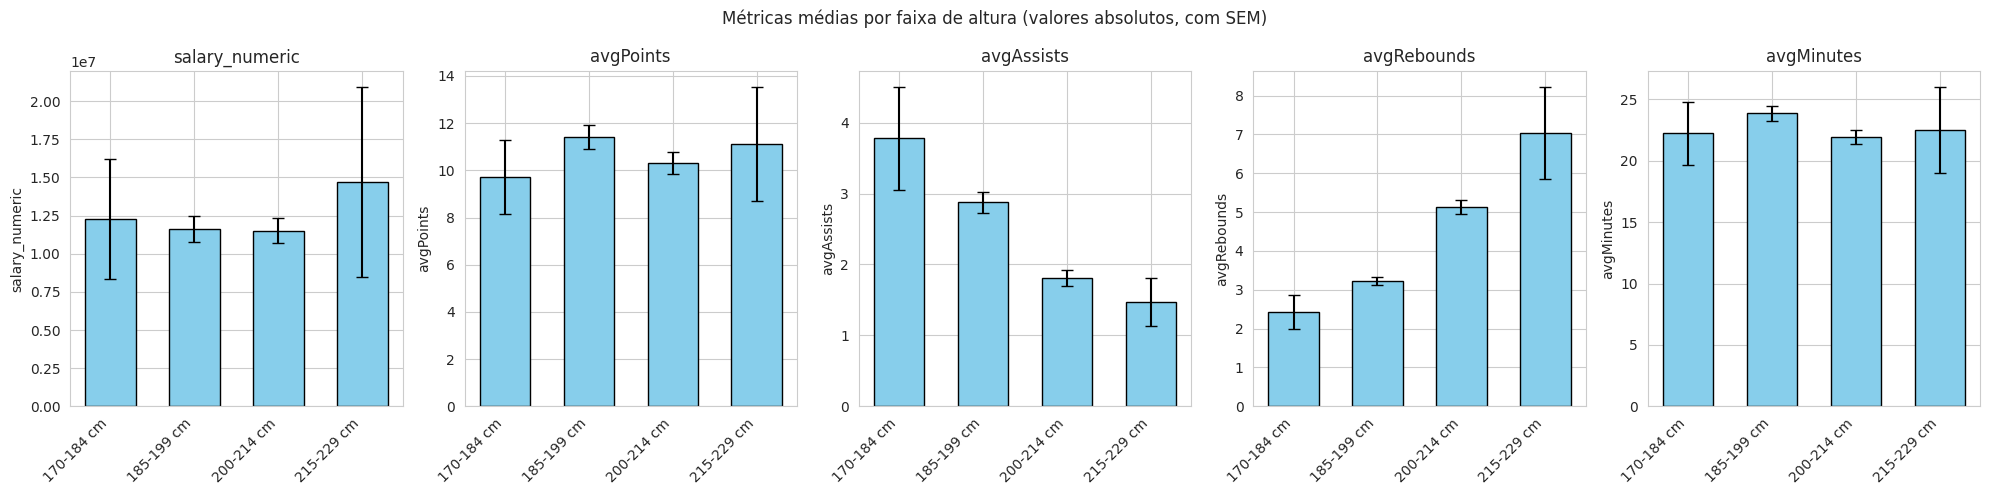

In [30]:

metrics = ["salary_numeric", "avgPoints", "avgAssists", "avgRebounds", "avgMinutes"]

x = np.arange(len(radar_mean))  # faixas de altura
width = 0.6

fig, axes = plt.subplots(1, len(metrics), figsize=(20,5), sharey=False)  #False pois escalas diferentes

for ax, metric in zip(axes, metrics):
    ax.bar(
        x,
        radar_mean[metric],
        width=width,
        yerr=radar_sem[metric],
        capsize=4,
        color='skyblue',
        edgecolor='black'
    )
    ax.set_xticks(x)
    ax.set_xticklabels(radar_mean.index, rotation=45, ha='right')
    ax.set_title(metric)
    ax.set_ylabel(metric)

plt.suptitle("Métricas médias por faixa de altura (valores absolutos, com SEM)")
plt.tight_layout()
plt.show()


In [31]:
height_mean_debug = df_unique_salary.groupby("height_group", observed=True)[metrics].mean()
height_mean_debug

,salary_numeric,avgPoints,avgAssists,avgRebounds,avgMinutes
height_group,,,,,
170-184 cm,1.225672e+07,9.730793,3.779793,2.423844,22.215012
185-199 cm,1.160958e+07,11.416481,2.874864,3.230066,23.856557
200-214 cm,1.152240e+07,10.317158,1.812979,5.128659,21.921566
215-229 cm,1.469304e+07,11.128890,1.465816,7.042940,22.490954


 Análise  por faixa de altura:

Com base no gráfico de radar e de barras que compara as métricas médias por faixa de altura, observa-se que os jogadores com maior média de minutos jogados se concentram na faixa de 185-199 cm. Essa maior exposição em quadra contribui diretamente para que eles também apresentem mais pontos em média.

No entanto, ao analisar o salário médio dentro dessas faixas, percebe-se que esses jogadores não estão entre os mais bem pagos, indicando que, embora joguem mais e pontuem mais, o salário médio nessa faixa não é o mais alto do conjunto de jogadores analisados.

In [32]:
top_player = df_unique_salary.loc[df_unique_salary['salary_numeric'].idxmax()].copy()
metrics = ["salary_numeric", "avgPoints", "avgAssists", "avgRebounds", "avgMinutes","birthplace"]
top_player_stats = top_player[["name"] + metrics].to_frame().T  # .T para virar tabela
top_player_stats.index = [top_player["name"]]  # nome do jogador como índice
print(top_player_stats)


                        name salary_numeric  avgPoints avgAssists avgRebounds  \
Stephen Curry  Stephen Curry     51915615.0  29.428572   6.285714    6.089286   

              avgMinutes birthplace  
Stephen Curry  34.660713  Akron, OH  


In [33]:
metrics_check = {
    "avgPoints": "Maior média de pontos",
    "avgAssists": "Maior média de assistências",
    "avgRebounds": "Maior média de rebotes",
    "salary_numeric": "Maior salário",
    "avgMinutes": "Maior média de minutos"
}

for col, desc in metrics_check.items():
    top_idx = df_unique_salary[col].idxmax()
    top_player = df_unique_salary.loc[top_idx]
    print(f"{desc}: {top_player['name']} ({col} = {top_player[col]})")


Maior média de pontos: Joel Embiid (avgPoints = 33.075756)
Maior média de assistências: Russell Westbrook (avgAssists = 11.7384615)
Maior média de rebotes: Andre Drummond (avgRebounds = 15.594936)
Maior salário: Stephen Curry (salary_numeric = 51915615.0)
Maior média de minutos: Fred VanVleet (avgMinutes = 37.876923)


In [34]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

metrics = ["salary_numeric", "avgPoints", "avgAssists", "avgRebounds", "avgMinutes"]

def gerar_radares_por_estado(df_unique_salary, min_jogadores=15):
    df_unique_salary["birthplace"] = df_unique_salary["birthplace"].astype(str)
    if "state" not in df_unique_salary.columns:
        df_unique_salary["state"] = df_unique_salary["birthplace"].str.extract(r",\s*([A-Z]{2})")[0]

    estados = df_unique_salary["state"].dropna().unique()
    radar_dfs = {}  # Para guardar DataFrames por estado

    for state in estados:
        df_state = df_unique_salary[df_unique_salary["state"] == state].copy()

        # Continuar apenas se houver pelo menos min_jogadores
        if len(df_state) < min_jogadores:
            continue

        # Certificar que existe height_group (criado anteriormente)
        if "height_group" not in df_state.columns:
            raise ValueError(f"O DataFrame não tem a coluna 'height_group'. Crie-a antes de chamar a função.")

        # Média e SEM
        radar_mean = df_state.groupby("height_group", observed=True)[metrics].mean()
        radar_sem = df_state.groupby("height_group", observed=True)[metrics].sem().fillna(0)

        # Normaliza
        radar_mean_scaled = radar_mean.copy()
        radar_sem_scaled = radar_sem.copy()
        for col in metrics:
            scaler = MinMaxScaler()
            radar_mean_scaled[[col]] = scaler.fit_transform(radar_mean[[col]])
            radar_sem_scaled[[col]] = scaler.fit_transform(radar_sem[[col]])

        # Guardar os DataFrames
        radar_dfs[state] = {
            "df_state": df_state.head(5),        # head(5) do dataset do estado CASO EU USE, DEBUG
            "radar_mean": radar_mean.head(5),
            "radar_sem": radar_sem.head(5),
            "radar_mean_scaled": radar_mean_scaled.head(5),
            "radar_sem_scaled": radar_sem_scaled.head(5)
        }

        plot_radar_with_colored_errorbars(radar_mean_scaled, radar_sem_scaled, metrics, title=f"Radar {state}")

    return radar_dfs

def plot_radar_with_colored_errorbars(df_mean, df_sem, metrics, title="Radar"):
    categories = metrics
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # fechar círculo

    fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(polar=True))

    for hg in df_mean.index:
        values = df_mean.loc[hg].tolist()
        sem_values = df_sem.loc[hg].tolist()
        values += values[:1]
        sem_values += sem_values[:1]

        line, = ax.plot(angles, values, label=hg, linewidth=2, marker='o')
        color = line.get_color()

        for angle, val, sem in zip(angles, values, sem_values):
            ax.plot([angle, angle], [val - sem, val + sem], color=color, linewidth=0.35)
            ax.plot([angle-0.02, angle+0.02], [val - sem, val - sem], color=color, linewidth=1.5)
            ax.plot([angle-0.02, angle+0.02], [val + sem, val + sem], color=color, linewidth=1.5)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(["0%","25%","50%","75%","100%"])
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()


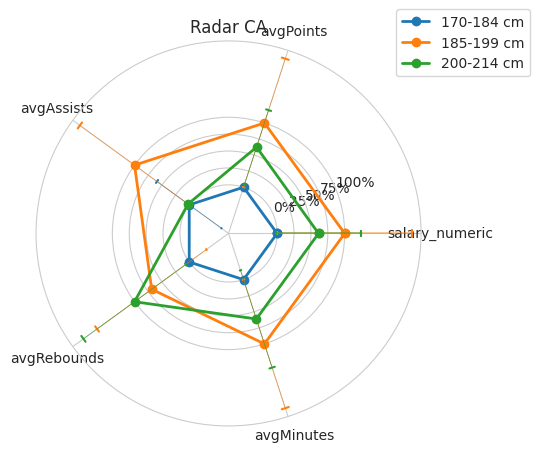

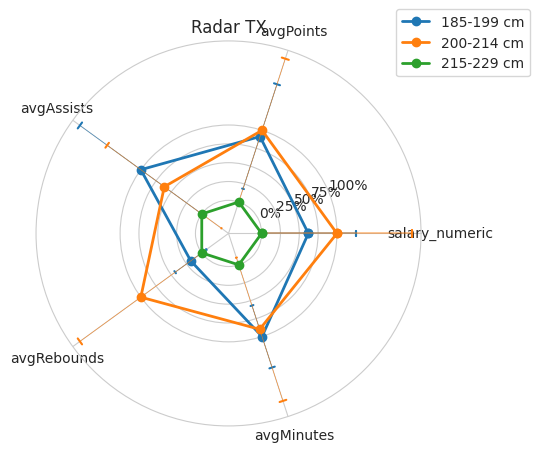

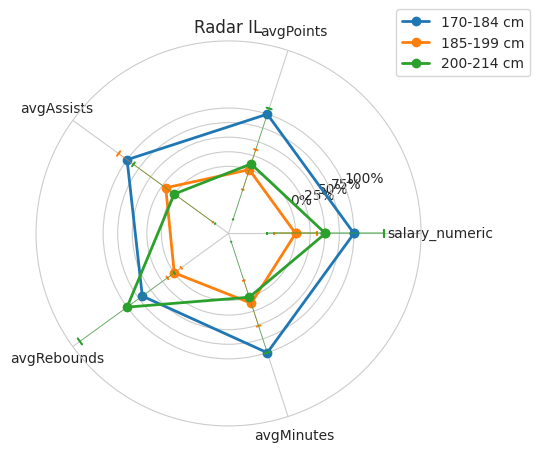

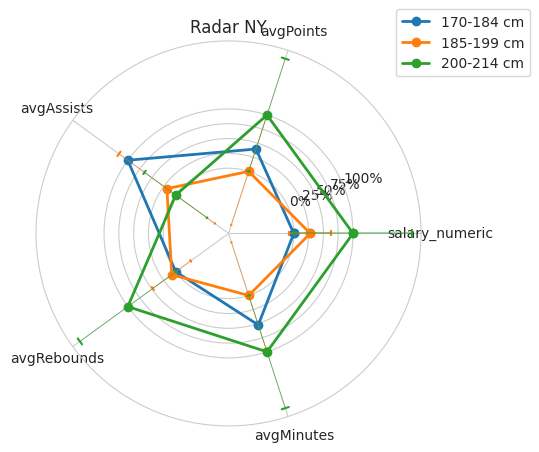

In [35]:
radars = gerar_radares_por_estado(df_unique_salary, min_jogadores=19)



In [36]:
# Filtrar LeBron James
lebron_df = df_unique_salary[df_unique_salary["name"] == "LeBron James"]
scurry_df = df_unique_salary[df_unique_salary["name"] == "Stephen Curry"]
scurry_df

,year,name,playerId,playerSlug,positionId,teamId,status,gamesPlayed,avgMinutes,avgFouls,...,birthplace,team,experience,rankingSalary,salary,altura_cm,peso_kg,salary_numeric,height_group,state
4794,2023,Stephen Curry,3975,stephen-curry,PG,GS,active,56.0,34.660713,2.089286,...,"Akron, OH",Golden State Warriors,13th Season,1,"$51,915,615",188.0,83.9,51915615.0,185-199 cm,OH


In [37]:
# Filtrar Stephen Curry
curry = df_unique_salary[df_unique_salary["name"] == "Stephen Curry"].iloc[0]

metrics_check = ["avgPoints", "avgAssists", "avgRebounds", "salary_numeric", "avgMinutes"]

for col in metrics_check:

    df_sorted = df_unique_salary.sort_values(col, ascending=False).reset_index()
    pos = df_sorted.index[df_sorted["name"] == "Stephen Curry"][0] + 1  # +1 para posição começando em 1
    print(f"Stephen Curry posição em {col}: {pos}")


Stephen Curry posição em avgPoints: 7
Stephen Curry posição em avgAssists: 20
Stephen Curry posição em avgRebounds: 91
Stephen Curry posição em salary_numeric: 1
Stephen Curry posição em avgMinutes: 29


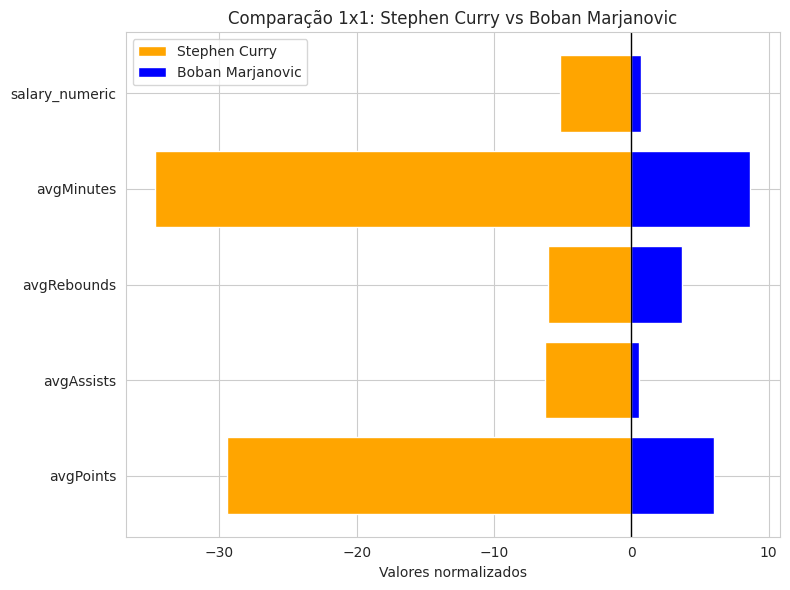

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Selecionar Curry e o jogador mais alto
metrics = ["avgPoints","avgAssists","avgRebounds","avgMinutes","salary_numeric"]

# Stephen Curry - mais bem pago
curry = df_unique_salary.loc[df_unique_salary["name"] == "Stephen Curry"]

# Jogador mais alto
tallest = df_unique_salary.loc[df_unique_salary["altura_cm"] == df_unique_salary["altura_cm"].max()]

# Criar DataFrame 1x1
df_1x1 = pd.concat([curry[metrics], tallest[metrics]])
df_1x1.index = [curry["name"].values[0], tallest["name"].values[0]]

# Normalizar cada coluna
df_1x1_norm = df_1x1.copy()
df_1x1_norm["salary_numeric"] = df_1x1_norm["salary_numeric"] / 1e7  # ajustar escala do salário

# Valores para o gráfico
player1 = df_1x1_norm.index[0]
player2 = df_1x1_norm.index[1]

values1 = -df_1x1_norm.loc[player1, metrics].values  # negativo para esquerda
values2 = df_1x1_norm.loc[player2, metrics].values   # positivo para direita

y = np.arange(len(metrics))

# Plot 1x1
fig, ax = plt.subplots(figsize=(8,6))

ax.barh(y, values1, color='orange', label=player1)
ax.barh(y, values2, color='blue', label=player2)

ax.set_yticks(y)
ax.set_yticklabels(metrics)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel("Valores normalizados")
ax.set_title(f"Comparação 1x1: {player1} vs {player2}")
ax.legend()
plt.tight_layout()
plt.show()


In [39]:
df_1x1_norm

,avgPoints,avgAssists,avgRebounds,avgMinutes,salary_numeric
Stephen Curry,29.428572,6.285714,6.089286,34.660713,5.191561
Boban Marjanovic,6.025641,0.564103,3.692308,8.666667,0.700000


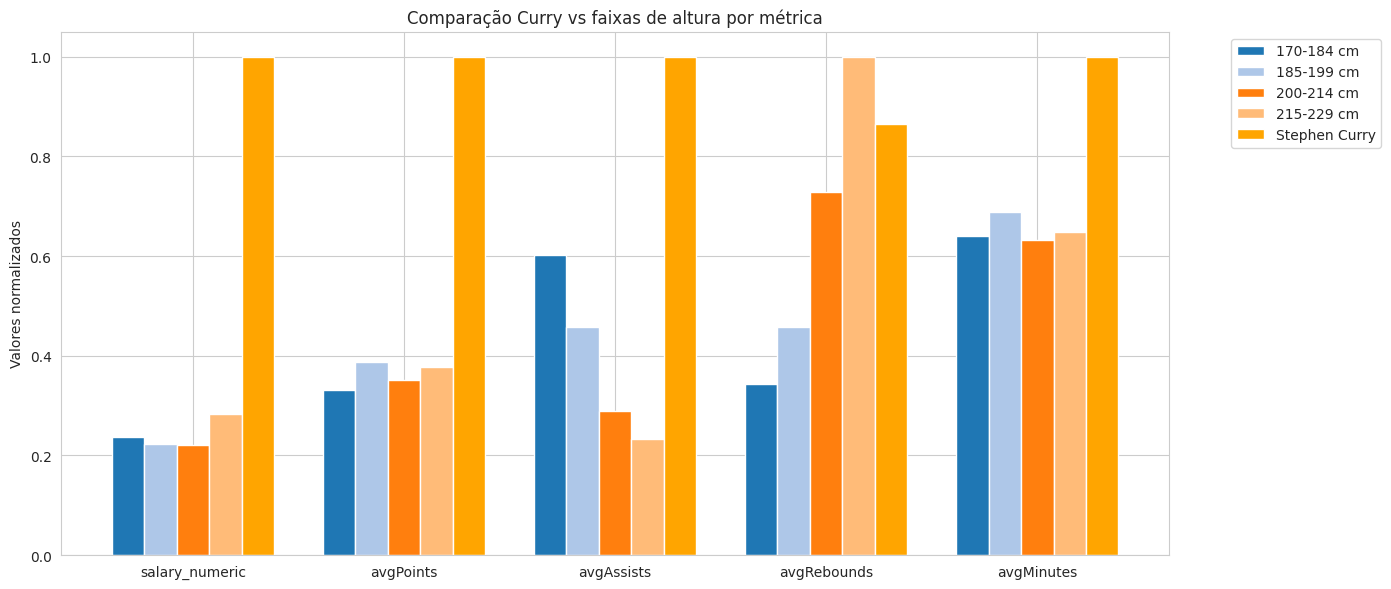

In [40]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["salary_numeric","avgPoints","avgAssists","avgRebounds","avgMinutes"]

# Média por height_group
height_mean = df_unique_salary.groupby("height_group", observed=True)[metrics].mean()

# Curry
curry = df_unique_salary.loc[df_unique_salary["name"]=="Stephen Curry", metrics].iloc[0]

# Normalizar por métrica (para que salário não esmague)
height_mean_norm = height_mean.copy()
curry_norm = curry.copy()
for col in metrics:
    max_val = max(height_mean[col].max(), curry[col])
    height_mean_norm[col] = height_mean[col] / max_val
    curry_norm[col] = curry[col] / max_val

n_groups = len(height_mean_norm)
bar_width = 0.8 / (n_groups + 1)  # ajustar para caber todos
colors = plt.cm.tab20.colors  # cores para os grupos

fig, ax = plt.subplots(figsize=(14,6))

x_start = 0
xticks = []
xtick_labels = []

for i, metric in enumerate(metrics):
    x = np.arange(n_groups + 1) * bar_width + x_start
    # Barras das faixas
    for j, hg in enumerate(height_mean_norm.index):
        ax.bar(x[j], height_mean_norm.loc[hg, metric], width=bar_width, color=colors[j], label=str(hg) if i==0 else "")
    # Barra do Curry
    ax.bar(x[-1], curry_norm[metric], width=bar_width, color='orange', label="Stephen Curry" if i==0 else "")

    # posição central do bloco
    xticks.append(x[0] + (x[-1]-x[0])/2)
    xtick_labels.append(metric)

    x_start = x[-1] + 0.4  # espaço para próximo bloco

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.set_ylabel("Valores normalizados")
ax.set_title("Comparação Curry vs faixas de altura por métrica")
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


In [41]:
# Média por ehight_group
height_mean_debug = df_unique_salary.groupby("height_group", observed=True)[metrics].mean()

# Curry
curry_stats = df_unique_salary.loc[df_unique_salary["name"]=="Stephen Curry", metrics].iloc[0]
df_debug = height_mean_debug.copy()
df_debug.loc["Stephen Curry"] = curry_stats
print(df_debug)


               salary_numeric  avgPoints  avgAssists  avgRebounds  avgMinutes
height_group                                                                 
170-184 cm       1.225672e+07   9.730793    3.779793     2.423844   22.215012
185-199 cm       1.160958e+07  11.416481    2.874864     3.230066   23.856557
200-214 cm       1.152240e+07  10.317158    1.812979     5.128659   21.921566
215-229 cm       1.469304e+07  11.128890    1.465816     7.042940   22.490954
Stephen Curry    5.191562e+07  29.428572    6.285714     6.089286   34.660713
